In [1]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
def parse_mums_file(filepath, label):
    """
    Parses a .mums file.
    - length: 1st column
    - present_count: number of non-empty values in 2nd column
    """
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 2:
                continue
            
            # 1st column is the length of the MUM
            length = int(parts[0])
            
            # 2nd column contains comma-separated indices/values
            # We count only the non-empty entries
            presence_list = [x.strip() for x in parts[1].split(',') if x.strip() != '']
            present_count = len(presence_list)
            
            is_consistent = 1 if len(set(presence_list)) == 1 else 0


            data.append({
                'Length': length,
                'Present_Count': present_count,
                'Location_Consistency': is_consistent,
                'Dataset': label
            })
    return pd.DataFrame(data)

def calculate_n50(lengths):
    if len(lengths) == 0: return 0
    sorted_lengths = np.sort(lengths)[::-1]
    total_sum = np.sum(sorted_lengths)
    cumulative_sum = np.cumsum(sorted_lengths)
    return sorted_lengths[np.where(cumulative_sum >= total_sum / 2)[0][0]]

In [32]:
base_path = "/home/Users/rdd4/mft-analyses/Figure2/data"
all_data = []

# 1. Identify all alpha folders
# This assumes folder names are like 'alpha_0.01', 'alpha_0.05', etc.
alpha_folders = [f for f in os.listdir(base_path) if f.startswith('alpha_')]

for folder_name in alpha_folders:
    # Extract the numerical value of alpha for easier plotting later
    try:
        alpha_val = float(folder_name.split('_')[1])
    except:
        alpha_val = folder_name # Fallback to string if naming is weird
        
    folder_full_path = os.path.join(base_path, folder_name)
    
    # 2. Define the files we expect in each folder
    # Format: (filename, label/w_value)
    target_files = [
        ('nucleotide.mums', 'Nucleotide'),
        ('mft_w5.mums', 'MFT (w=5)'),
        ('mft_w8.mums', 'MFT (w=8)'),
        ('mft_w11.mums', 'MFT (w=11)')
    ]
    
    for filename, w_label in target_files:
        filepath = os.path.join(folder_full_path, filename)
        
        if os.path.exists(filepath):
            # Use your existing parsing function
            temp_df = parse_mums_file(filepath, w_label)
            
            # Add the alpha metadata to every row
            temp_df['Alpha'] = alpha_val
            
            all_data.append(temp_df)
        else:
            print(f"Warning: {filepath} not found.")

# 3. Combine everything into one master DataFrame
df_master = pd.concat(all_data, ignore_index=True)
df_master

,Length,Present_Count,Location_Consistency,Dataset,Alpha
0,29,2,1,Nucleotide,0.015
1,54,47,1,Nucleotide,0.015
2,52,48,1,Nucleotide,0.015
3,50,49,1,Nucleotide,0.015
4,48,50,1,Nucleotide,0.015
...,...,...,...,...,...
4761932,46,90,1,MFT (w=11),0.005
4761933,38,91,1,MFT (w=11),0.005
4761934,33,92,1,MFT (w=11),0.005
4761935,32,95,1,MFT (w=11),0.005


In [58]:
## Due to bug/feature of mumemto in that the short sequences can sometimes lead to MUMs that are much longer than the actual sequence, we filter out MUMs longer than 10,000 bp for the analysis. This is a very conservative threshold and should not affect the results since most MUMs are expected to be much shorter than this.

df_final = df_master[df_master['Length'] <= 10000]
df_final

,Length,Present_Count,Location_Consistency,Dataset,Alpha,Alpha_str
0,29,2,1,Nucleotide,0.015,0.015
1,54,47,1,Nucleotide,0.015,0.015
2,52,48,1,Nucleotide,0.015,0.015
3,50,49,1,Nucleotide,0.015,0.015
4,48,50,1,Nucleotide,0.015,0.015
...,...,...,...,...,...,...
4761932,46,90,1,MFT (w=11),0.005,0.005
4761933,38,91,1,MFT (w=11),0.005,0.005
4761934,33,92,1,MFT (w=11),0.005,0.005
4761935,32,95,1,MFT (w=11),0.005,0.005


In [59]:
summary_df = df_final.groupby(['Alpha', 'Dataset']).apply(
    lambda x: pd.Series({
        'N50': calculate_n50(x['Length'].values),
        'Total_MUMs': len(x)
    })
).reset_index()

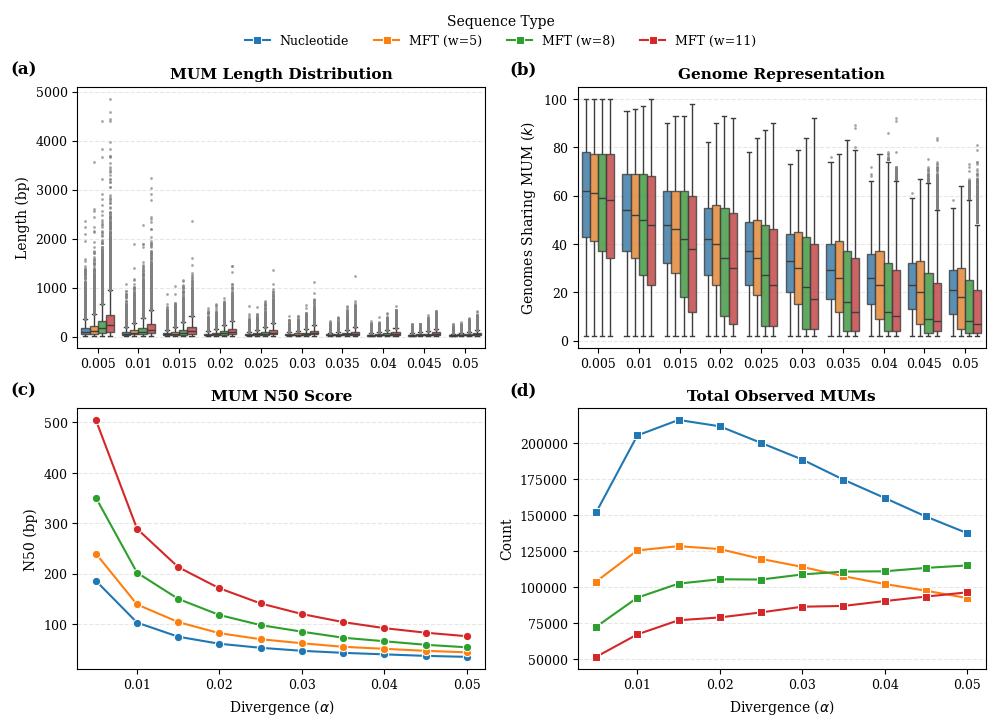

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Academic Styling Setup
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# Define shared order and parameters
hue_order = ['Nucleotide', 'MFT (w=5)', 'MFT (w=8)', 'MFT (w=11)']
flierprops = dict(marker='o', markersize=2, alpha=0.7, markeredgecolor='none', markerfacecolor='gray')

# 2. Create Figure (Standard column width ~10 inches)
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

# --- (a) TOP LEFT: MUM Length ---
ax = axes[0, 0]
sns.boxplot(data=df_final, x='Alpha', y='Length', hue='Dataset', hue_order=hue_order,
            ax=ax, flierprops=flierprops, palette="tab10", boxprops={'alpha': 0.8})
ax.set_title('MUM Length Distribution', fontweight='bold')
ax.set_ylabel('Length (bp)')
ax.set_xlabel('')

# --- (b) TOP RIGHT: Genomes Count ---
ax = axes[0, 1]
sns.boxplot(data=df_final, x='Alpha', y='Present_Count', hue='Dataset', hue_order=hue_order,
            ax=ax, flierprops=flierprops, palette="tab10", boxprops={'alpha': 0.8})
ax.set_title('Genome Representation', fontweight='bold')
ax.set_ylabel('Genomes Sharing MUM ($k$)')
ax.set_xlabel('')

# --- (c) BOTTOM LEFT: N50 ---
ax = axes[1, 0]
sns.lineplot(data=summary_df, x='Alpha', y='N50', hue='Dataset', hue_order=hue_order,
             ax=ax, marker='o', palette="tab10", markersize=6, linewidth=1.5)
ax.set_title('MUM N50 Score', fontweight='bold')
ax.set_ylabel('N50 (bp)')
ax.set_xlabel(r'Divergence ($\alpha$)')

# --- (d) BOTTOM RIGHT: Total MUMs ---
ax = axes[1, 1]
sns.lineplot(data=summary_df, x='Alpha', y='Total_MUMs', hue='Dataset', hue_order=hue_order,
             ax=ax, marker='s', palette="tab10", markersize=6, linewidth=1.5)
ax.set_title('Total Observed MUMs', fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel(r'Divergence ($\alpha$)')

# 3. Final Polishing
subplot_labels = ['a', 'b', 'c', 'd']
for i, ax in enumerate(axes.flat):
    # Add (a), (b), (c), (d) labels
    ax.text(-0.1, 1.1, f'({subplot_labels[i]})', transform=ax.transAxes, 
            fontsize=12, fontweight='bold', va='top', ha='right')
    
    # Consistent Grid
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Remove internal legends
    if ax.get_legend():
        ax.get_legend().remove()

# 4. Global Legend (Top Center/Right)
handles, labels = axes[1, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.04), 
           ncol=4, frameon=False, title="Sequence Type")

plt.tight_layout()
# Adjust to make room for top legend
plt.subplots_adjust(top=0.92) 

plt.savefig('Figure2.png', dpi=300, bbox_inches='tight')
plt.savefig('Figure2.svg', dpi=300, bbox_inches='tight')
plt.savefig('Figure2.pdf', dpi=300, bbox_inches='tight')

plt.show()
